In [22]:
!pip install -q ultralytics gradio

In [3]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

model = YOLO("/content/best (18).pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [20]:
image_path = "/content/images (16).jpg"

# Prediction
results = model.predict(
    source=image_path,
    conf=0.5,
    iou=0.1 ,
    save=False
)


image 1/1 /content/images (16).jpg: 704x832 1 Manholes, 677.1ms
Speed: 6.0ms preprocess, 677.1ms inference, 0.9ms postprocess per image at shape (1, 3, 704, 832)


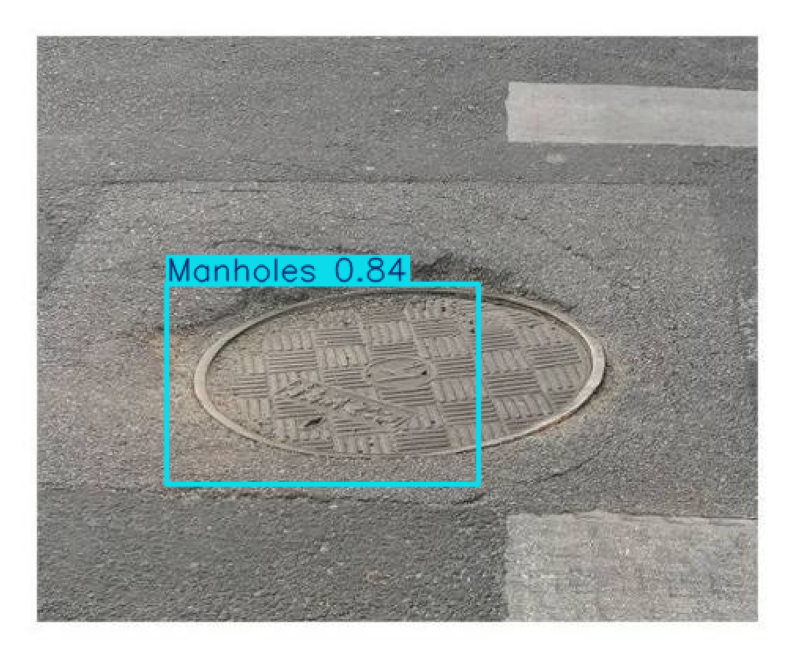

In [21]:
result_image = results[0].plot()

plt.figure(figsize=(10, 10))
plt.imshow(result_image[:, :, ::-1])   # BGR -> RGB
plt.axis("off")
plt.show()

In [24]:
import gradio as gr
from ultralytics import YOLO
from PIL import Image


model = YOLO("/content/best (18).pt")

def detect(image, conf, iou):
    results = model.predict(
        image,
        conf=conf,
        iou=iou
    )

    output = Image.fromarray(results[0].plot()[..., ::-1])
    return output

app = gr.Interface(
    fn=detect,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Slider(0.0, 1.0, value=0.25, step=0.05, label="Confidence"),
        gr.Slider(0.0, 1.0, value=0.45, step=0.05, label="IoU Threshold"),
    ],
    outputs=gr.Image(type="pil", label="Detection Result"),
    title="YOLO Detection",
    description="Upload an image and adjust the Confidence and IoU thresholds."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2a937c56852e88fc6c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
